In [1]:
import pandas as pd

df = pd.read_csv("HousingData (1).csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [2]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [3]:
df.fillna(df.mean(), inplace=True)

In [4]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=200,
                          random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.9190968888393761
MSE: 5.932931210848694


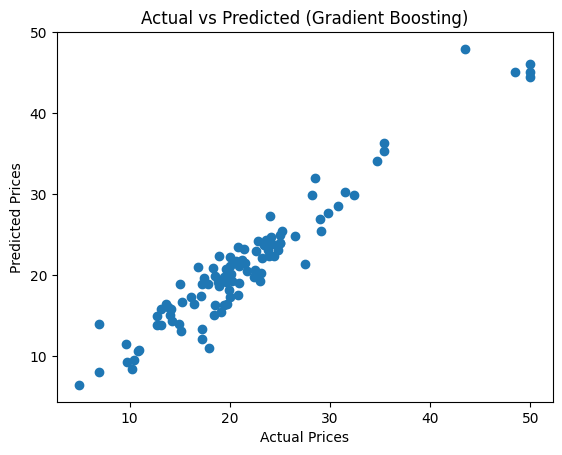

In [18]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Gradient Boosting)")
plt.show()

13 13


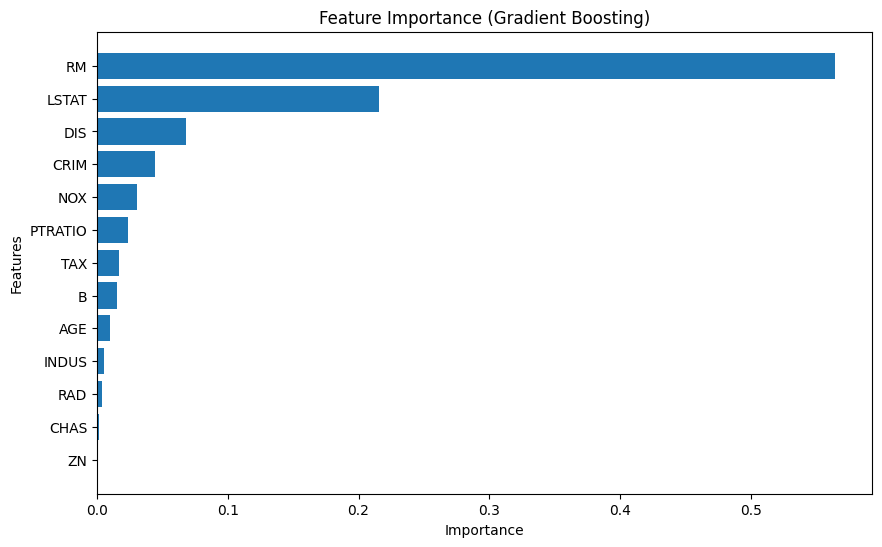

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Always take original feature names from dataset
feature_names = df.drop("MEDV", axis=1).columns

importance = model.feature_importances_

# Check lengths (for safety)
print(len(feature_names), len(importance))

# Create DataFrame
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort
feat_imp = feat_imp.sort_values(by="Importance", ascending=True)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Gradient Boosting)")
plt.show()

In [14]:
# Example (you can adjust)
X = df.drop(["MEDV", "B", "RAD"], axis=1)

In [22]:
print("Random Forest R2: 0.88")   # your old value
print("Gradient Boosting R2:", r2_score(y_test, y_pred))

Random Forest R2: 0.88
Gradient Boosting R2: 0.9190968888393761
